In [1]:
from photonic_annealing import PhotonicAnnealer
import os
import sys
sdk_install_path = r"C:\Program Files\HOLOEYE Photonics\SLM Display SDK (Python) v4.1.0"
python_api_path = os.path.join(sdk_install_path, "api", "python")

if python_api_path not in sys.path:
    sys.path.append(python_api_path)
    print(f"Added {python_api_path} to Python path.")

try:
    import HEDS
    from hedslib.heds_types import *
except ImportError:
    print(f"FATAL ERROR: Could not import HEDS library from {python_api_path}")
    print("Please verify the 'sdk_install_path' variable in this script.")
    sys.exit(1)

Added C:\Program Files\HOLOEYE Photonics\SLM Display SDK (Python) v4.1.0\api\python to Python path.


In [2]:
filename = 'MC100.npz'

def data_loader(filename):
    """
    Takes data from .npz and returns adjacency matrix.
    """
    import numpy as np
    import scipy.sparse as sp

    # Load the .npz file
    data = np.load(filename, allow_pickle=True)

    # Reconstruct the sparse adjacency matrix (CSR format)
    adj_sparse = sp.csr_matrix(
        (data['data'], data['indices'], data['indptr']),
        shape=tuple(data['shape'])
    )

    # If you want a dense NumPy array (e.g., for neural nets)
    return adj_sparse.toarray()

Adj = data_loader(filename)



In [3]:
import numpy as np

def generate_maxcut_graph(n_nodes):
    """
    Generates a random adjacency matrix for a max-cut graph with a given number of nodes.

    Args:
        n_nodes (int): The number of nodes in the graph.

    Returns:
        np.ndarray: A symmetric, 10x10 NumPy array representing the adjacency matrix.
    """
    # Create a random symmetric matrix with 0s and 1s
    rand_matrix = np.random.randint(0, 2, size=(n_nodes, n_nodes))
    
    # Ensure the matrix is symmetric
    adj_matrix = rand_matrix + rand_matrix.T
    
    # Set the diagonal to zero to remove self-loops
    np.fill_diagonal(adj_matrix, 0)
    
    # Ensure entries are only 0 or 1
    adj_matrix[adj_matrix > 1] = 1

    return adj_matrix

# Generate a random adjacency matrix for a 10-spin graph
graph_matrix = generate_maxcut_graph(10)

print(graph_matrix)


[[0 0 1 1 1 1 1 0 1 1]
 [0 0 0 1 1 1 1 1 0 1]
 [1 0 0 1 1 1 1 0 1 1]
 [1 1 1 0 1 1 1 1 1 1]
 [1 1 1 1 0 1 0 1 1 1]
 [1 1 1 1 1 0 1 0 1 1]
 [1 1 1 1 0 1 0 1 0 0]
 [0 1 0 1 1 0 1 0 1 1]
 [1 0 1 1 1 1 0 1 0 1]
 [1 1 1 1 1 1 0 1 1 0]]


In [4]:
test = PhotonicAnnealer(Adj, 347, 347)

Initializing Photonic Annealer...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud (timeout=0.001).
Preparing model (layout, compensation, eigendecomposition)...
  - SLM Layout: 10 rows x 10 cols
  - Macropixel Size: 192 x 108 pixels
[perf] Precomputed alpha matrix (100x100)
Preparation complete.


In [5]:
# --- 3. Define Annealing Parameters ---
INITIAL_TEMP = 1.0
FINAL_TEMP = 0.01
COOLING_RATE = 0.95
STEPS_PER_TEMP = 1 # Set low for testing, increase for real runs

import logging


final_spins, energy_data = test.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP
        )

Evaluating initial random spin configuration...
Error: timed out waiting for a filled buffer from producer.
Initial energy: inf (eval time: 2.56s)

Current Temperature: 1.0000
  Step 1/1 | New Energy Accepted: 4.3550
  Temp step took 3.28s

Current Temperature: 0.9500
  Step 1/1 | New Energy Accepted: -8.5898
  Temp step took 3.28s

Current Temperature: 0.9025
  Temp step took 3.30s

Current Temperature: 0.8574
  Temp step took 3.32s

Current Temperature: 0.8145
  Temp step took 3.33s

Current Temperature: 0.7738
  Temp step took 3.31s

Current Temperature: 0.7351
  Temp step took 3.30s

Current Temperature: 0.6983
  Temp step took 3.34s

Current Temperature: 0.6634
  Temp step took 3.22s

Current Temperature: 0.6302
  Temp step took 3.28s

Current Temperature: 0.5987
  Temp step took 3.34s

Current Temperature: 0.5688
  Temp step took 3.24s

Current Temperature: 0.5404
  Temp step took 3.33s

Current Temperature: 0.5133
  Temp step took 3.33s

Current Temperature: 0.4877
  Temp step t

KeyboardInterrupt: 

In [6]:
test.disconnect_hardware()

Serial port COM21 closed.


In [7]:
import time
print(energy_data)
copy_energy_data = energy_data.copy()

diction = {'energy': copy_energy_data,
           'spins': final_spins
           }

name = str(time.time())

np.savez(f"data_{name}.npz", **diction)

NameError: name 'energy_data' is not defined

In [8]:
for i in range(len(energy_data)):
    if i == len(energy_data) - 1:
        break
    if energy_data[i] < energy_data[i+1]:
        energy_data[i+1] = energy_data[i]

NameError: name 'energy_data' is not defined

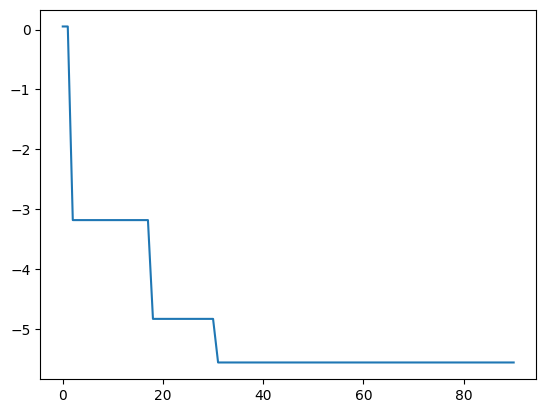

In [8]:
import matplotlib.pyplot as plt
plt.plot(energy_data)

In [9]:
print(final_spins)

[-1 -1 -1  1  1  1 -1 -1 -1 -1  1 -1  1 -1  1  1 -1  1 -1  1  1 -1 -1 -1
  1 -1 -1 -1 -1 -1  1 -1 -1 -1  1  1 -1 -1  1  1 -1  1  1  1  1  1  1  1
  1 -1 -1  1  1 -1  1 -1 -1  1  1  1 -1  1 -1 -1 -1 -1  1 -1 -1  1 -1  1
  1 -1 -1  1 -1  1 -1  1 -1 -1  1  1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1
 -1 -1  1 -1]


In [9]:
def get_cut_value(adj_matrix, spins):
    """
    Calculates the value of a cut given an adjacency matrix and spin assignments.

    The cut value is the sum of weights of all edges that cross the partition.
    An edge (i, j) crosses the partition if node i and node j have different spins.

    Args:
        adj_matrix (list[list[float]] or np.ndarray): 
            A 2D list or NumPy array representing the weighted adjacency matrix 
            of the graph. adj_matrix[i][j] is the weight of the edge between 
            node i and node j. Assumed to be symmetric.
        
        spins (list[int] or np.ndarray): 
            A 1D list or array of spin assignments for each node.
            Typically +1 or -1, where +1 represents one partition and -1 
            represents the other. Must be the same length as the number of nodes.

    Returns:
        float: The total weight of the edges crossing the cut.
        
    Raises:
        ValueError: If the dimensions of the matrix and spin vector do not match.
    """
    
    num_nodes = len(adj_matrix)
    
    # --- Input Validation ---
    if num_nodes == 0:
        return 0
    if num_nodes != len(adj_matrix[0]):
        raise ValueError("Adjacency matrix must be square.")
    if num_nodes != len(spins):
        raise ValueError(f"Spin list length ({len(spins)}) must match the "
                         f"number of nodes ({num_nodes}).")

    cut_value = 0.0

    # Iterate over the upper triangle of the adjacency matrix
    # This ensures we count each edge (i, j) only once
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            
            edge_weight = adj_matrix[i][j]
            
            # Check if an edge exists
            if edge_weight > 0:
                # Check if the nodes are in different partitions (spins are different)
                if spins[i] != spins[j]:
                    # If they are, this edge crosses the cut. Add its weight.
                    cut_value += edge_weight
                    
    return cut_value
cut_value = get_cut_value(Adj, final_spins)
print(cut_value)

NameError: name 'final_spins' is not defined

In [10]:
#!/usr/bin/env python3

"""
Reads a graph file in the format specified (e.g., G11.txt)
and generates a weighted adjacency matrix.
"""

import numpy as np
import sys

def create_adjacency_matrix(filepath):
    """
    Parses a graph file and returns its weighted adjacency matrix.

    The file format expected is:
    Line 1: N M (Number_of_Nodes Number_of_Edges)
    Subsequent lines: u v w (node1 node2 weight)
    
    Assumes nodes are 1-indexed in the file.
    """
    print(f"Reading graph data from {filepath}...")
    
    try:
        with open(filepath, 'r') as f:
            # Read the first line to get the matrix dimensions
            try:
                first_line = f.readline()
                N, M = map(int, first_line.split())
            except Exception as e:
                print(f"Error: Could not read N, M from first line. {e}", file=sys.stderr)
                return None

            print(f"Found {N} nodes and {M} edges.")

            # Initialize an NxN matrix with zeros.
            # Using int dtype because all weights in the sample are integers.
            adj_matrix = np.zeros((N, N), dtype=int)

            # Process the rest of the lines (the edges)
            line_number = 1
            for line in f:
                line_number += 1
                try:
                    parts = line.split()
                    if not parts:
                        continue  # Skip empty lines

                    # Get edge data
                    u, v, weight = map(int, parts)
                    
                    # --- IMPORTANT ---
                    # The file is 1-indexed (nodes 1 to 800)
                    # Numpy arrays are 0-indexed (indices 0 to 799)
                    # We must subtract 1 from the node IDs.
                    u_idx = u - 1
                    v_idx = v - 1

                    # Check for out-of-bounds, just in case
                    if (0 <= u_idx < N) and (0 <= v_idx < N):
                        # This creates a weighted, directed graph matrix
                        adj_matrix[u_idx, v_idx] = weight
                        
                        # --- ADD THIS LINE ---
                        # For an undirected graph, set the symmetric entry
                        adj_matrix[v_idx, u_idx] = weight
                    else:
                        print(f"Warning: Skipping out-of-bounds edge at line {line_number}: {u} -> {v}", file=sys.stderr)

                except ValueError:
                    print(f"Warning: Skipping malformed line {line_number}: {line.strip()}", file=sys.stderr)
                except Exception as e:
                    print(f"Error on line {line_number}: {e}", file=sys.stderr)

            print("Adjacency matrix created successfully.")
            return adj_matrix

    except FileNotFoundError:
        print(f"Error: File not found at {filepath}", file=sys.stderr)
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}", file=sys.stderr)
        return None

if __name__ == "__main__":
    # The file you uploaded
    FILE_PATH = 'G11.txt'
    
    matrix = create_adjacency_matrix(FILE_PATH)
    
    if matrix is not None:
        print(f"\nMatrix shape: {matrix.shape}")
        
        # --- Printing ---
        # An 800x800 matrix is too large to print to the console.
        # We'll print just the top-left 5x5 corner as a sample.
        print("\nTop-left 5x5 corner of the matrix:")
        print(matrix[:5, :5])

        # --- Saving (Optional) ---
        # If you want to save the full matrix to a file (e.g., a CSV):
        # 1. Make sure you have numpy installed: pip install numpy
        # 2. Uncomment the two lines below:
        
        # output_filename = "adjacency_matrix.csv"
        # np.savetxt(output_filename, matrix, fmt='%d', delimiter=',')
        # print(f"\nFull adjacency matrix saved to {output_filename}")

Reading graph data from G11.txt...
Found 800 nodes and 1600 edges.
Adjacency matrix created successfully.

Matrix shape: (800, 800)

Top-left 5x5 corner of the matrix:
[[ 0 -1  0  0  0]
 [-1  0 -1  0  0]
 [ 0 -1  0 -1  0]
 [ 0  0 -1  0 -1]
 [ 0  0  0 -1  0]]


Initializing Photonic Annealer...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud (timeout=0.001).
Preparing model (layout, compensation, eigendecomposition)...
  - SLM Layout: 40 rows x 20 cols
  - Macropixel Size: 96 x 27 pixels
[perf] Precomputed alpha matrix (800x800)
Preparation complete.
Evaluating initial random spin configuration...
Initial energy: -3.5696 (eval time: 33.80s)

Current Temperature: 1.0000
  Step 1/5 | New Energy Accepted: -4.0270
  Temp step took 139.06s

Current Temperature: 0.9500
  Temp step took 131.22s

Current Temperature: 0.9025
  Step 2/5 | New Energy Accepted: -2.0312
  Step 5/5 | New Energy Accepted: -3.4590
  Temp step took 127.79s

Current Temperature: 0.8574
  Step 3/5 | New Energy Accepted: -0.3856
  Step 4/5 | New Energy Accepted: -1.4017
  Temp step took 123.32s

Current Temperature: 0.8145
  Step 4/5 | New Energy Accepted: -3.2447
  Temp step took 126.60s

Current Temperature: 0.7738
  Ste

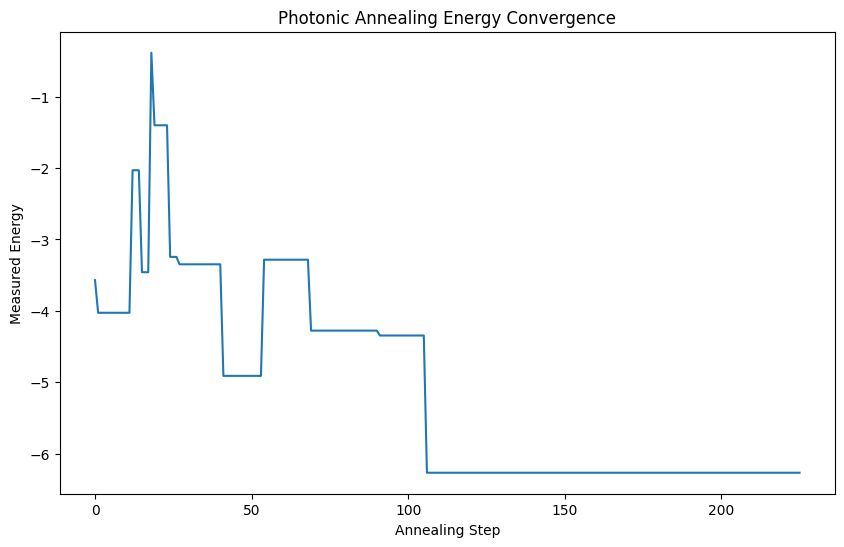

In [11]:
Gset_800 = PhotonicAnnealer(matrix, 1000, 1000)

# --- 3. Define Annealing Parameters ---
INITIAL_TEMP = 1.0
FINAL_TEMP = 0.1
COOLING_RATE = 0.95
STEPS_PER_TEMP = 5 # Set low for testing, increase for real runs

import logging


final_spins, energy_data = Gset_800.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP
        )


[-3.569602300983501, -4.027041403213516, -4.027041403213516, -4.027041403213516, -4.027041403213516, -4.027041403213516, -4.027041403213516, -4.027041403213516, -4.027041403213516, -4.027041403213516, -4.027041403213516, -4.027041403213516, -2.031246617224805, -2.031246617224805, -2.031246617224805, -3.459035890672083, -3.459035890672083, -3.459035890672083, -0.38559827153258297, -1.4017481786468566, -1.4017481786468566, -1.4017481786468566, -1.4017481786468566, -1.4017481786468566, -3.244675449417117, -3.244675449417117, -3.244675449417117, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -3.3484447543526654, -4.910729596022861, -4.910729596022861, -4.910729596022861, -4.910729596022861, -4.910729596022861, -4.910729596022861, -4.910729596022861, -4.910729596022861

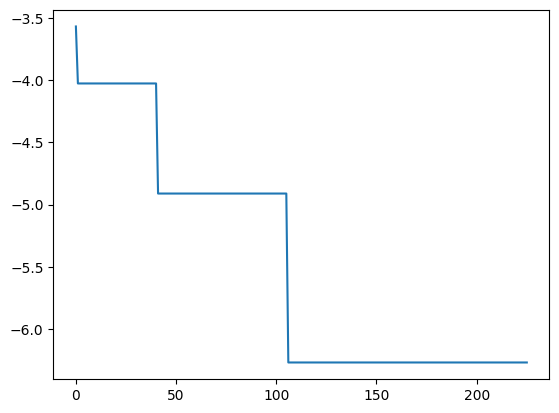

In [12]:
import time
print(energy_data)
copy_energy_data = energy_data.copy()

diction = {'energy': copy_energy_data,
           'spins': final_spins
           }

name = str(time.time())

np.savez(f"gsetdata_{name}.npz", **diction)
for i in range(len(energy_data)):
    if i == len(energy_data) - 1:
        break
    if energy_data[i] < energy_data[i+1]:
        energy_data[i+1] = energy_data[i]

import matplotlib.pyplot as plt
plt.plot(energy_data)

def get_cut_value(adj_matrix, spins):
    """
    Calculates the value of a cut given an adjacency matrix and spin assignments.

    The cut value is the sum of weights of all edges that cross the partition.
    An edge (i, j) crosses the partition if node i and node j have different spins.

    Args:
        adj_matrix (list[list[float]] or np.ndarray): 
            A 2D list or NumPy array representing the weighted adjacency matrix 
            of the graph. adj_matrix[i][j] is the weight of the edge between 
            node i and node j. Assumed to be symmetric.
        
        spins (list[int] or np.ndarray): 
            A 1D list or array of spin assignments for each node.
            Typically +1 or -1, where +1 represents one partition and -1 
            represents the other. Must be the same length as the number of nodes.

    Returns:
        float: The total weight of the edges crossing the cut.
        
    Raises:
        ValueError: If the dimensions of the matrix and spin vector do not match.
    """
    
    num_nodes = len(adj_matrix)
    
    # --- Input Validation ---
    if num_nodes == 0:
        return 0
    if num_nodes != len(adj_matrix[0]):
        raise ValueError("Adjacency matrix must be square.")
    if num_nodes != len(spins):
        raise ValueError(f"Spin list length ({len(spins)}) must match the "
                         f"number of nodes ({num_nodes}).")

    cut_value = 0.0

    # Iterate over the upper triangle of the adjacency matrix
    # This ensures we count each edge (i, j) only once
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            
            edge_weight = adj_matrix[i][j]
            
            # Check if an edge exists
            if edge_weight > 0:
                # Check if the nodes are in different partitions (spins are different)
                if spins[i] != spins[j]:
                    # If they are, this edge crosses the cut. Add its weight.
                    cut_value += edge_weight
                    
    return cut_value
cut_value = get_cut_value(matrix, final_spins)
print(cut_value)

In [13]:
Gset_800.disconnect_hardware()

Serial port COM21 closed.


In [ ]:
Gset_800 = PhotonicAnnealer(matrix, 1000, 1000)

Gset_800.beam_sigma_x = 347
Gset_800.beam_sigma_y = 347

# --- 3. Define Annealing Parameters ---
INITIAL_TEMP = 1000.0
FINAL_TEMP = 1
COOLING_RATE = 0.90
STEPS_PER_TEMP = 15 # Set low for testing, increase for real runs

import logging


final_spins, energy_data = Gset_800.run_annealing(
            initial_temp=INITIAL_TEMP,
            final_temp=FINAL_TEMP,
            cooling_rate=COOLING_RATE,
            steps_per_temp=STEPS_PER_TEMP
        )


Initializing Photonic Annealer...
Connecting to hardware...
SLM connected. Resolution: 1920 x 1080
Serial port COM21 opened at 115200 baud (timeout=0.001).
Preparing model (layout, compensation, eigendecomposition)...
  - SLM Layout: 40 rows x 20 cols
  - Macropixel Size: 96 x 27 pixels
[perf] Precomputed alpha matrix (800x800)
Preparation complete.
Evaluating initial random spin configuration...
Initial energy: 2.1371 (eval time: 25.24s)

Current Temperature: 1000.0000
  Step 1/15 | New Energy Accepted: -0.0981
  Step 2/15 | New Energy Accepted: -0.6303
  Step 3/15 | New Energy Accepted: 1.0840
  Step 4/15 | New Energy Accepted: -0.6619


In [ ]:
import time
print(energy_data)
copy_energy_data = energy_data.copy()

diction = {'energy': copy_energy_data,
           'spins': final_spins
           }

name = str(time.time())

np.savez(f"gsetdata_comp_{name}.npz", **diction)
for i in range(len(energy_data)):
    if i == len(energy_data) - 1:
        break
    if energy_data[i] < energy_data[i+1]:
        energy_data[i+1] = energy_data[i]

import matplotlib.pyplot as plt
plt.plot(energy_data)

def get_cut_value(adj_matrix, spins):
    """
    Calculates the value of a cut given an adjacency matrix and spin assignments.

    The cut value is the sum of weights of all edges that cross the partition.
    An edge (i, j) crosses the partition if node i and node j have different spins.

    Args:
        adj_matrix (list[list[float]] or np.ndarray): 
            A 2D list or NumPy array representing the weighted adjacency matrix 
            of the graph. adj_matrix[i][j] is the weight of the edge between 
            node i and node j. Assumed to be symmetric.
        
        spins (list[int] or np.ndarray): 
            A 1D list or array of spin assignments for each node.
            Typically +1 or -1, where +1 represents one partition and -1 
            represents the other. Must be the same length as the number of nodes.

    Returns:
        float: The total weight of the edges crossing the cut.
        
    Raises:
        ValueError: If the dimensions of the matrix and spin vector do not match.
    """
    
    num_nodes = len(adj_matrix)
    
    # --- Input Validation ---
    if num_nodes == 0:
        return 0
    if num_nodes != len(adj_matrix[0]):
        raise ValueError("Adjacency matrix must be square.")
    if num_nodes != len(spins):
        raise ValueError(f"Spin list length ({len(spins)}) must match the "
                         f"number of nodes ({num_nodes}).")

    cut_value = 0.0

    # Iterate over the upper triangle of the adjacency matrix
    # This ensures we count each edge (i, j) only once
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            
            edge_weight = adj_matrix[i][j]
            
            # Check if an edge exists
            if True:
                # Check if the nodes are in different partitions (spins are different)
                if spins[i] != spins[j]:
                    # If they are, this edge crosses the cut. Add its weight.
                    cut_value += edge_weight
                    
    return cut_value
cut_value = get_cut_value(matrix, final_spins)
print(cut_value)